In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import string
import random

/opt/anaconda3/envs/newtf/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [2]:
train=pd.read_csv('archive/sign_mnist_test.csv')
test=pd.read_csv('archive/sign_mnist_test.csv')
train

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,6,149,149,150,150,150,151,151,150,151,...,138,148,127,89,82,96,106,112,120,107
1,5,126,128,131,132,133,134,135,135,136,...,47,104,194,183,186,184,184,184,182,180
2,10,85,88,92,96,105,123,135,143,147,...,68,166,242,227,230,227,226,225,224,222
3,0,203,205,207,206,207,209,210,209,210,...,154,248,247,248,253,236,230,240,253,255
4,3,188,191,193,195,199,201,202,203,203,...,26,40,64,48,29,46,49,46,46,53
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7167,1,135,119,108,102,105,99,61,103,121,...,108,112,116,114,118,180,184,176,167,163
7168,12,157,159,161,164,166,166,171,174,175,...,213,213,213,214,213,211,210,210,209,208
7169,2,190,191,190,191,190,190,192,192,191,...,216,215,213,214,214,213,210,211,209,208
7170,4,201,205,208,209,214,216,218,223,226,...,112,169,255,255,237,113,91,67,70,63


In [3]:
tungtungtung=tf.convert_to_tensor(train.drop('label',axis=1))
balerinacapuchina=tf.convert_to_tensor(test.drop('label',axis=1))
tungtungtung

<tf.Tensor: shape=(7172, 784), dtype=int64, numpy=
array([[149, 149, 150, ..., 112, 120, 107],
       [126, 128, 131, ..., 184, 182, 180],
       [ 85,  88,  92, ..., 225, 224, 222],
       ...,
       [190, 191, 190, ..., 211, 209, 208],
       [201, 205, 208, ...,  67,  70,  63],
       [173, 174, 173, ..., 195, 193, 192]])>

In [4]:
trainlabel= keras.utils.to_categorical(train['label'])
testlabel= keras.utils.to_categorical(test['label'])
trainlabel.shape

(7172, 25)

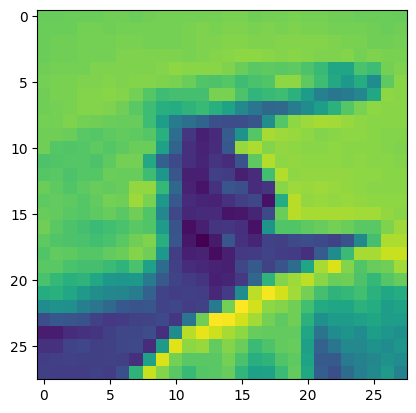

In [5]:
def show_img(ahihidongoc):
    ahihidongoc=tf.reshape(ahihidongoc,[-1,28,28])
    plt.imshow(ahihidongoc[0])
    plt.show()

show_img(tungtungtung)

In [6]:
minmax=MinMaxScaler()
tungtungtung=minmax.fit_transform(tungtungtung)
tungtungtung= tf.reshape(tungtungtung,[-1,28,28,1])
balerinacapuchina=minmax.fit_transform(balerinacapuchina)
balerinacapuchina= tf.reshape(balerinacapuchina,[-1,28,28,1])
tungtungtung

<tf.Tensor: shape=(7172, 28, 28, 1), dtype=float64, numpy=
array([[[[0.58431373],
         [0.58431373],
         [0.58823529],
         ...,
         [0.58823529],
         [0.58823529],
         [0.58431373]],

        [[0.58823529],
         [0.58823529],
         [0.58823529],
         ...,
         [0.59215686],
         [0.58823529],
         [0.59215686]],

        [[0.58823529],
         [0.59215686],
         [0.59215686],
         ...,
         [0.59215686],
         [0.59215686],
         [0.59607843]],

        ...,

        [[0.27058824],
         [0.27058824],
         [0.30196078],
         ...,
         [0.45490196],
         [0.44313725],
         [0.4627451 ]],

        [[0.29019608],
         [0.29411765],
         [0.29803922],
         ...,
         [0.43137255],
         [0.45490196],
         [0.44313725]],

        [[0.29411765],
         [0.29019608],
         [0.29019608],
         ...,
         [0.43921569],
         [0.47058824],
         [0.41960784]]],


 

In [7]:
X_train, X_val, y_train, y_val=train_test_split(tungtungtung.numpy(), trainlabel, test_size=0.33)
X_train=tf.convert_to_tensor(X_train)
X_val=tf.convert_to_tensor(X_val)

In [8]:
simplemodel=keras.Sequential([
    layers.InputLayer(shape=(28,28,1)),
    layers.Conv2D(64,kernel_size=(3,3), strides=(2,2),activation='relu'),
    layers.MaxPool2D(pool_size=3),
    layers.Conv2D(128,kernel_size=(5,5), strides=(1,1),padding='same',activation='relu'),
    layers.Conv2D(256,kernel_size=(5,5), strides=(1,1),padding='same',activation='relu'),
    layers.MaxPool2D(pool_size=3,strides=(2,2)),
    layers.Flatten(),
    layers.Dense(32,activation='relu'),
    layers.Dense(25,activation='softmax')
])

In [9]:
simplemodel.summary()
simplemodel.compile(optimizer ='adam', loss ='categorical_crossentropy', metrics =['accuracy'])
simplemodel.fit(X_train, y_train, batch_size=64, epochs=5,validation_data=(X_val,y_val))

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 13, 13, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 4, 4, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 256)      │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 1, 1, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 25)             │           825 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,034,073 (3.94 MB)

 Trainable params: 1,034,073 (3.94 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.1203 - loss: 3.0075 - val_accuracy: 0.2450 - val_loss: 2.5271
Epoch 2/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.4460 - loss: 1.8253 - val_accuracy: 0.6223 - val_loss: 1.2693
Epoch 3/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.7130 - loss: 0.9571 - val_accuracy: 0.7883 - val_loss: 0.7007
Epoch 4/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.8624 - loss: 0.4818 - val_accuracy: 0.8589 - val_loss: 0.4534
Epoch 5/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.9380 - loss: 0.2578 - val_accuracy: 0.9480 - val_loss: 0.2212


In [10]:
predicted= simplemodel.predict(balerinacapuchina)
predicted=np.argmax(predicted, axis=1)
testlabel=np.argmax(testlabel, axis=1)

225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


              precision    recall  f1-score   support

           A       0.89      1.00      0.94       331
           B       1.00      1.00      1.00       432
           C       0.94      0.99      0.97       310
           D       0.85      0.99      0.92       245
           E       1.00      0.98      0.99       498
           F       1.00      1.00      1.00       247
           G       0.84      1.00      0.92       348
           H       0.99      0.91      0.94       436
           I       1.00      1.00      1.00       288
           K       1.00      1.00      1.00       331
           L       0.88      1.00      0.94       209
           M       0.99      0.90      0.94       394
           N       0.94      0.97      0.95       291
           O       1.00      0.96      0.98       246
           P       1.00      1.00      1.00       347
           Q       1.00      0.98      0.99       164
           R       0.91      0.86      0.89       144
           S       0.98    

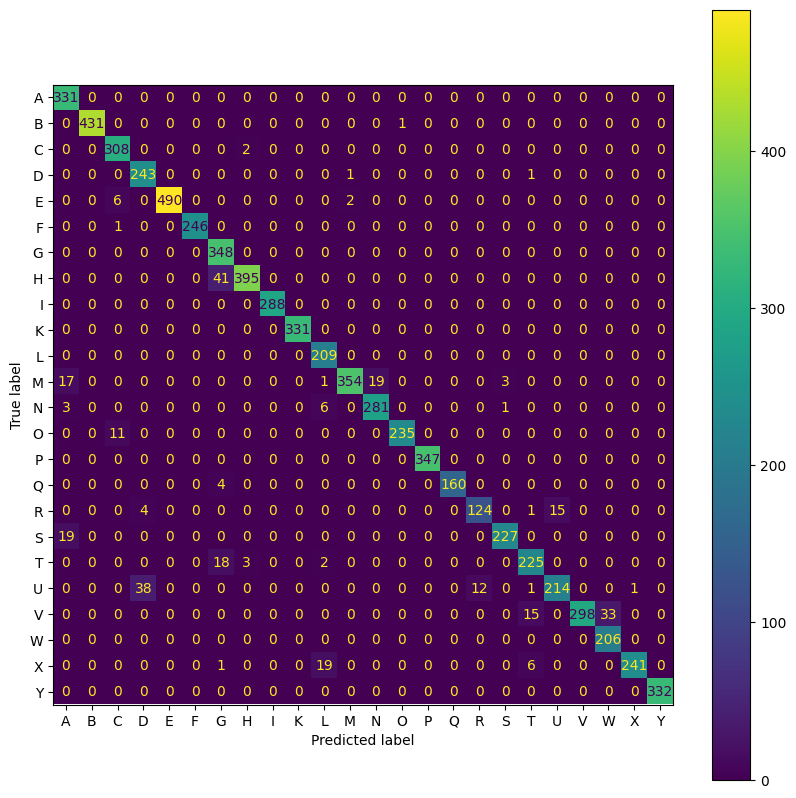

In [11]:
translation_table=str.maketrans("", "", "JZ")
alphabelt= list(string.ascii_uppercase.translate(translation_table))

print(classification_report(testlabel,predicted,target_names=alphabelt))
cm = confusion_matrix(testlabel, predicted)
cmp = ConfusionMatrixDisplay(cm, display_labels=alphabelt)
fig, ax = plt.subplots(figsize=(10,10))
cmp.plot(ax=ax)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


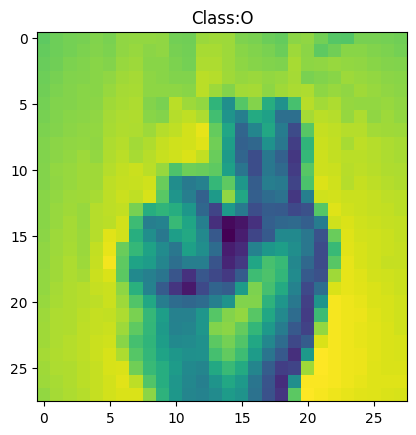

In [12]:
def show_randomresult_img(ahihidongoc,model):
    ahihidongoc=tf.reshape(ahihidongoc,[-1,28,28,1])
    Gojo_satoru=ahihidongoc[random.randint(0,len(ahihidongoc)-1)]
    plt.imshow(Gojo_satoru)
    Gojo_satoru=tf.expand_dims(Gojo_satoru, axis=0)
    pred=model.predict(Gojo_satoru)
    pred=np.argmax(pred, axis=1)
    plt.title(f'Class:{alphabelt[pred[0]]}')
    plt.show()

show_randomresult_img(balerinacapuchina,simplemodel)

In [13]:
Alexnet=keras.Sequential([
    layers.InputLayer(shape=(28,28,1)),
    layers.Resizing(224,224),
    layers.Conv2D(64,kernel_size=(11,11), strides=(2,2),padding='same',activation='relu'),
    layers.MaxPool2D(pool_size=3,strides=(2,2)),
    layers.Conv2D(128,kernel_size=(5,5), strides=(1,1),padding='same',activation='relu'),
    layers.MaxPool2D(pool_size=3,strides=(2,2)),
    layers.Conv2D(256,kernel_size=(3,3), strides=(1,1),padding='same',activation='relu'),
    layers.Conv2D(128,kernel_size=(3,3), strides=(1,1),padding='same',activation='relu'),
    layers.Conv2D(64,kernel_size=(3,3), strides=(1,1),padding='same',activation='relu'),
    layers.MaxPool2D(pool_size=3,strides=(2,2)),
    layers.Flatten(),
    layers.Dense(4096,activation='relu'),
    layers.Dropout(0.25),
    layers.Dense(4096,activation='relu'),
    layers.Dropout(0.25),
    layers.Dense(25,activation='softmax')
])

In [14]:
Alexnet.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │         7,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 55, 55, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 55, 55, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 27, 27, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 27, 27, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 27, 27, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 27, 27, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 10816)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4096)           │    44,306,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 25)             │       102,425 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,066,905 (236.77 MB)

 Trainable params: 62,066,905 (236.77 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
Alexnet.compile(optimizer ='adam', loss ='categorical_crossentropy', metrics =['accuracy'])
Alexnet.fit(X_train, y_train, batch_size=64, epochs=5,validation_data=(X_val,y_val))

Epoch 1/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 152s 2s/step - accuracy: 0.0712 - loss: 3.2313 - val_accuracy: 0.1893 - val_loss: 2.8696
Epoch 2/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 185s 2s/step - accuracy: 0.5525 - loss: 1.4141 - val_accuracy: 0.9058 - val_loss: 0.2872
Epoch 3/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 215s 3s/step - accuracy: 0.9575 - loss: 0.1378 - val_accuracy: 0.9911 - val_loss: 0.0235
Epoch 4/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 216s 3s/step - accuracy: 0.9913 - loss: 0.0311 - val_accuracy: 0.9996 - val_loss: 0.0043
Epoch 5/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 228s 3s/step - accuracy: 0.9921 - loss: 0.0288 - val_accuracy: 0.9975 - val_loss: 0.0078


In [16]:
predicted= Alexnet.predict(balerinacapuchina)
predicted=np.argmax(predicted, axis=1)

225/225 ━━━━━━━━━━━━━━━━━━━━ 84s 372ms/step


              precision    recall  f1-score   support

           A       1.00      1.00      1.00       331
           B       1.00      0.98      0.99       432
           C       1.00      1.00      1.00       310
           D       1.00      1.00      1.00       245
           E       1.00      1.00      1.00       498
           F       0.96      1.00      0.98       247
           G       1.00      0.99      0.99       348
           H       0.99      1.00      1.00       436
           I       1.00      1.00      1.00       288
           K       1.00      1.00      1.00       331
           L       1.00      1.00      1.00       209
           M       1.00      1.00      1.00       394
           N       1.00      1.00      1.00       291
           O       1.00      1.00      1.00       246
           P       1.00      1.00      1.00       347
           Q       1.00      1.00      1.00       164
           R       1.00      1.00      1.00       144
           S       1.00    

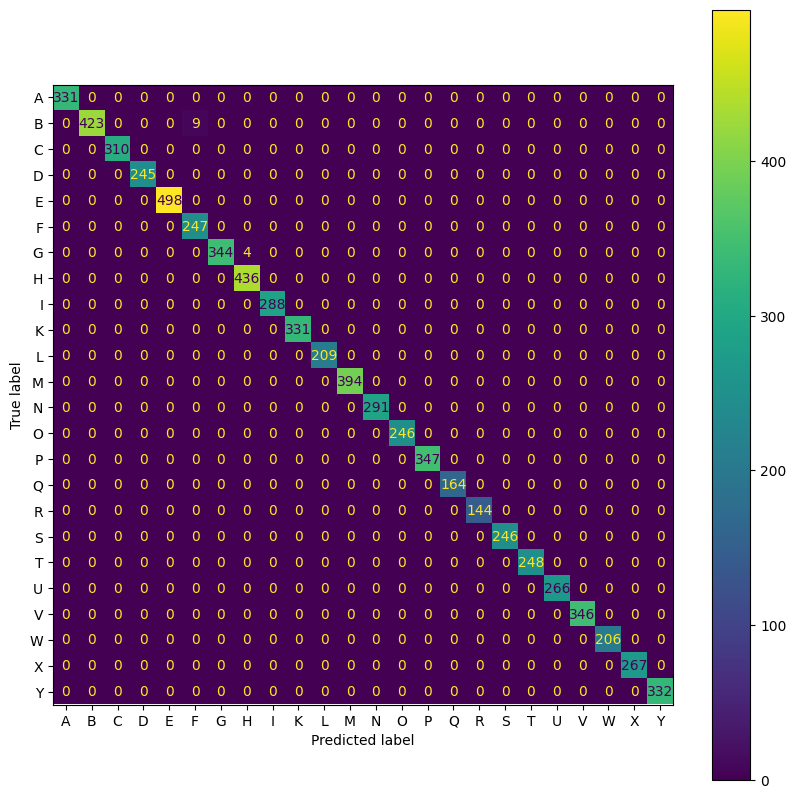

In [17]:
print(classification_report(testlabel,predicted,target_names=alphabelt))
cm = confusion_matrix(testlabel, predicted)
cmp = ConfusionMatrixDisplay(cm, display_labels=alphabelt)
fig, ax = plt.subplots(figsize=(10,10))
cmp.plot(ax=ax)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


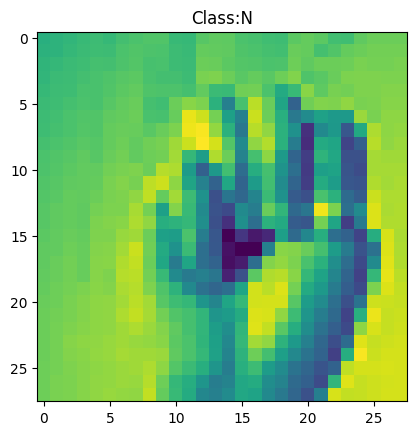

In [18]:
show_randomresult_img(balerinacapuchina,Alexnet)